Using Colab cache for faster access to the 'student-mental-health-and-resilience-dataset' dataset.
Path to dataset files: /kaggle/input/student-mental-health-and-resilience-dataset

First 5 Rows
   Student_ID  Age  Gender   GPA  Stress_Level  Anxiety_Score  \
0           1   23   Other  2.52             5             20   
1           2   19    Male  2.74             5              3   
2           3   21  Female  3.53             5             11   
3           4   18    Male  2.04             4             15   
4           5   19   Other  2.87             1              2   

   Depression_Score                                  Daily_Reflections  \
0                 6  Onto foreign do environmental anyone every nea...   
1                 7  Party but others visit admit industry country ...   
2                24  Religious sure wait do chance decade according...   
3                14            A task effect entire coach join series.   
4                 4  Knowledge several camer

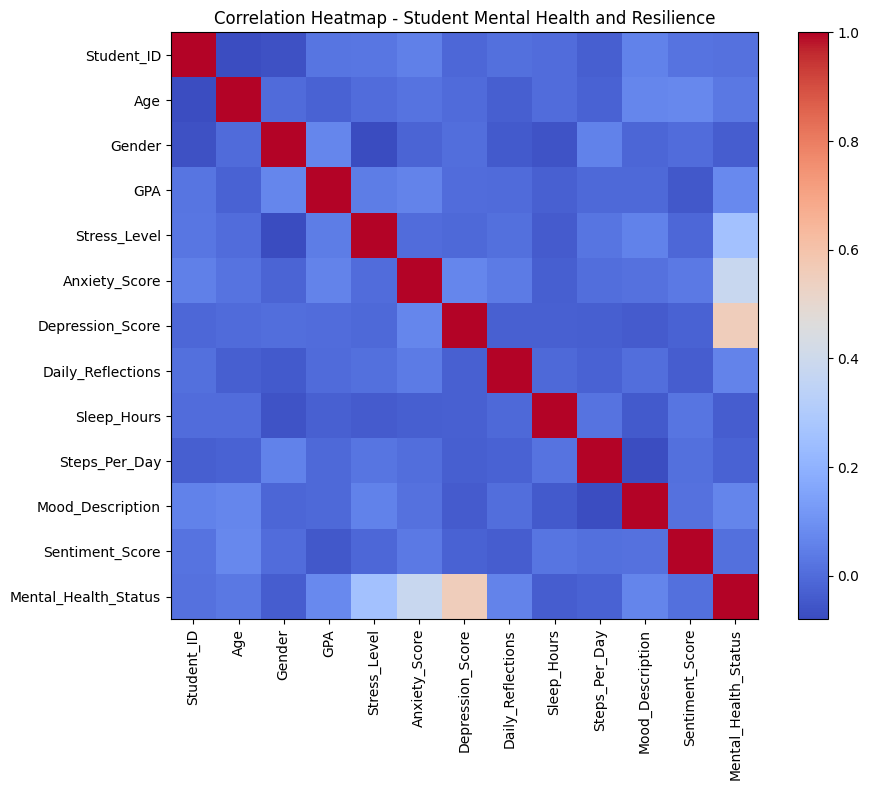

In [7]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, LabelEncoder

path = kagglehub.dataset_download(
    "ziya07/student-mental-health-and-resilience-dataset"
)

print("Path to dataset files:", path)

files = os.listdir(path)

csv_files = [
    file for file in files
    if file.endswith(".csv")
]

csv_file = csv_files[0]

df = pd.read_csv(
    os.path.join(path, csv_file),
    engine="python",
    on_bad_lines="skip"
)

print("\nFirst 5 Rows")
print(df.head())

print("\nMissing Values")
print(df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

df.drop_duplicates(inplace=True)

num_cols = df.select_dtypes(
    include=np.number
).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

scaler = MinMaxScaler()

df[num_cols] = scaler.fit_transform(
    df[num_cols]
)

encoder = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

corr = df.select_dtypes(
    include="number"
).corr()

plt.figure(figsize=(10,8))

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title(
    "Correlation Heatmap - Student Mental Health and Resilience"
)

plt.tight_layout()

plt.show()

In [2]:
# @title
import kagglehub # Download latest version path = kagglehub.dataset_download( "ziya07/student-mental-health-and-resilience-dataset" ) print("Path to dataset files:", path)